## Olympics Analysis

### Database connection and SQL query

In [1]:
# Import modules

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

In [2]:
# Establish connection

load_dotenv("../.env")
db_url = os.getenv("DATABASE_URL", default=None)
assert db_url is not None, "DATABASE_URL not found in .env"
engine = create_engine(db_url)

In [3]:
df = pd.read_sql("""
    SELECT 
        a.name,
        a.sex,
        s.sport,
        d.year,
        m.medal_name,
        f.age_at_event,
        f.body_size_at_event,
        f.body_weight_at_event,
        c.country_name
    FROM fact_medals f
        JOIN dim_athletes a     ON f.athlete            = a.athleteid
        JOIN dim_event e        ON f.event              = e.eventid
        JOIN dim_sport s        ON e.sportid            = s.sportid
        JOIN dim_date d         ON f.dateid             = d.dateid
        JOIN dim_countries c    ON f.country_at_event   = c.countryid
        LEFT JOIN dim_medal m   ON f.medal              = m.medalid
""", engine)

### Exploratory Data Analysis

In [4]:
# General Overview

print(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165978 entries, 0 to 165977
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   name                  165978 non-null  object 
 1   sex                   165978 non-null  object 
 2   sport                 165978 non-null  object 
 3   year                  165978 non-null  int64  
 4   medal_name            23536 non-null   object 
 5   age_at_event          165978 non-null  int64  
 6   body_size_at_event    158604 non-null  float64
 7   body_weight_at_event  158277 non-null  float64
 8   country_name          165959 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 11.4+ MB
None


,year,age_at_event,body_size_at_event,body_weight_at_event
count,165978.000000,165978.000000,158604.000000,158277.000000
mean,1991.359795,24.821862,1755.384858,706.471073
std,16.811584,5.992564,110.561177,149.443828
min,1960.000000,0.000000,1270.000000,77.000000
25%,1976.000000,21.000000,1680.000000,600.000000
50%,1992.000000,24.000000,1750.000000,700.000000
75%,2004.000000,28.000000,1830.000000,790.000000
max,2016.000000,71.000000,2260.000000,2140.000000


In [5]:
# Data quality - missing values

# Percentage distribution of missing values
print(df.isna().sum().sort_values(ascending=False))
print(df.isna().mean().sort_values(ascending=False) * 100)
print(df.shape)

medal_name              142442
body_weight_at_event      7701
body_size_at_event        7374
country_name                19
name                         0
year                         0
sport                        0
sex                          0
age_at_event                 0
dtype: int64
medal_name              85.819807
body_weight_at_event     4.639772
body_size_at_event       4.442757
country_name             0.011447
name                     0.000000
year                     0.000000
sport                    0.000000
sex                      0.000000
age_at_event             0.000000
dtype: float64
(165978, 9)


**Result:**
- Missing values are present in country_name, body_weight and body_size.
- Strategy for country_name: Delete, as there is very little data and it is categorical
- Strategy for body_*: Further investigation (see below)

In [6]:
print(df["body_weight_at_event"].isnull().groupby([df["year"], df["sport"]]).sum().sort_values(ascending=False))
print(f"\n{"-"*90}\n")
print(df[df["sport"] == "Swimming"].info())

year  sport        
1992  Swimming         483
1996  Swimming         364
1992  Gymnastics       262
1976  Swimming         257
1996  Gymnastics       215
                      ... 
2016  Trampolining       0
      Volleyball         0
      Water Polo         0
      Weightlifting      0
      Wrestling          0
Name: body_weight_at_event, Length: 409, dtype: int64

------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 19866 entries, 19 to 165964
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  19866 non-null  object 
 1   sex                   19866 non-null  object 
 2   sport                 19866 non-null  object 
 3   year                  19866 non-null  int64  
 4   medal_name            2429 non-null   object 
 5   age_at_event          19866 non-null  int64  
 6   body_size_at_event

**Result:**
- Certain sports are more affected by missing data (swimming, gymnastics) -> Missing not at random (MNAR)
- For the sport of swimming and gymnastics, approximately 7% of the data for weight and height is missing. It seems sensible to impute these values using the median for each sport and gender

In [7]:
# Perform data cleansing

print(f"Rows before dropna: {len(df)}")
df = df.dropna(subset=['country_name']) # Remove rows without 'country_name'
print(f"Rows after dropna: {len(df)}")

Rows before dropna: 165978
Rows after dropna: 165959


In [8]:
# Perform imputation

df['body_size_at_event'] = df.groupby(['sport', 'sex'])['body_size_at_event'].transform(lambda x: x.fillna(x.median()))

df['body_weight_at_event'] = df.groupby(['sport', 'sex'])['body_weight_at_event'].transform(lambda x: x.fillna(x.median()))

In [9]:
print(df[['body_size_at_event', 'body_weight_at_event']].isna().sum())

body_size_at_event      0
body_weight_at_event    0
dtype: int64


### Peak age analysis — when do athletes in each sport reach their performance peak?

In [10]:
# Filter by medal winners
mask_medals = df['medal_name'].notnull()
df_peak_age = df[mask_medals]

In [11]:
# Calculate the median age of medallists

df_peak_age.groupby(['sport', 'sex'])['age_at_event'].median().rename("Medianes Medaillenalter")

sport          sex
Archery        F      23.0
               M      24.0
Athletics      F      25.0
               M      25.0
Badminton      F      25.0
                      ... 
Water Polo     M      26.0
Weightlifting  F      23.0
               M      25.0
Wrestling      F      26.0
               M      26.0
Name: Medianes Medaillenalter, Length: 68, dtype: float64

In [12]:
# The age range in which 75% of the medals are awarded

df_peak_age.groupby(['sport', 'sex'])['age_at_event'].quantile([0.125, 0.875]).unstack(level=-1).rename(columns={0.125 : "12.5%-Quartil", 0.875 : "87.5%-Quartil"})

12.5%-Quartil  87.5%-Quartil
sport         sex                              
Archery       F           18.375         29.000
              M           19.000         31.625
Athletics     F           21.000         30.000
              M           21.000         30.000
Badminton     F           21.000         27.000
...                          ...            ...
Water Polo    M           22.000         31.000
Weightlifting F           20.000         27.000
              M           21.000         30.000
Wrestling     F           21.000         31.000
              M           22.000         30.000

[68 rows x 2 columns]

In [13]:
df_peak_summary = pd.concat([df_peak_age.groupby(['sport', 'sex'])['age_at_event'].median().rename("Medianes Medaillenalter"),df_peak_age.groupby(['sport', 'sex'])['age_at_event'].quantile([0.125, 0.875]).unstack(level=-1).rename(columns={0.125 : "12.5%-Quartil", 0.875 : "87.5%-Quartil"})], axis=1)

display(df_peak_summary)

Medianes Medaillenalter  12.5%-Quartil  87.5%-Quartil
sport         sex                                                       
Archery       F                       23.0         18.375         29.000
              M                       24.0         19.000         31.625
Athletics     F                       25.0         21.000         30.000
              M                       25.0         21.000         30.000
Badminton     F                       25.0         21.000         27.000
...                                    ...            ...            ...
Water Polo    M                       26.0         22.000         31.000
Weightlifting F                       23.0         20.000         27.000
              M                       25.0         21.000         30.000
Wrestling     F                       26.0         21.000         31.000
              M                       26.0         22.000         30.000

[68 rows x 3 columns]

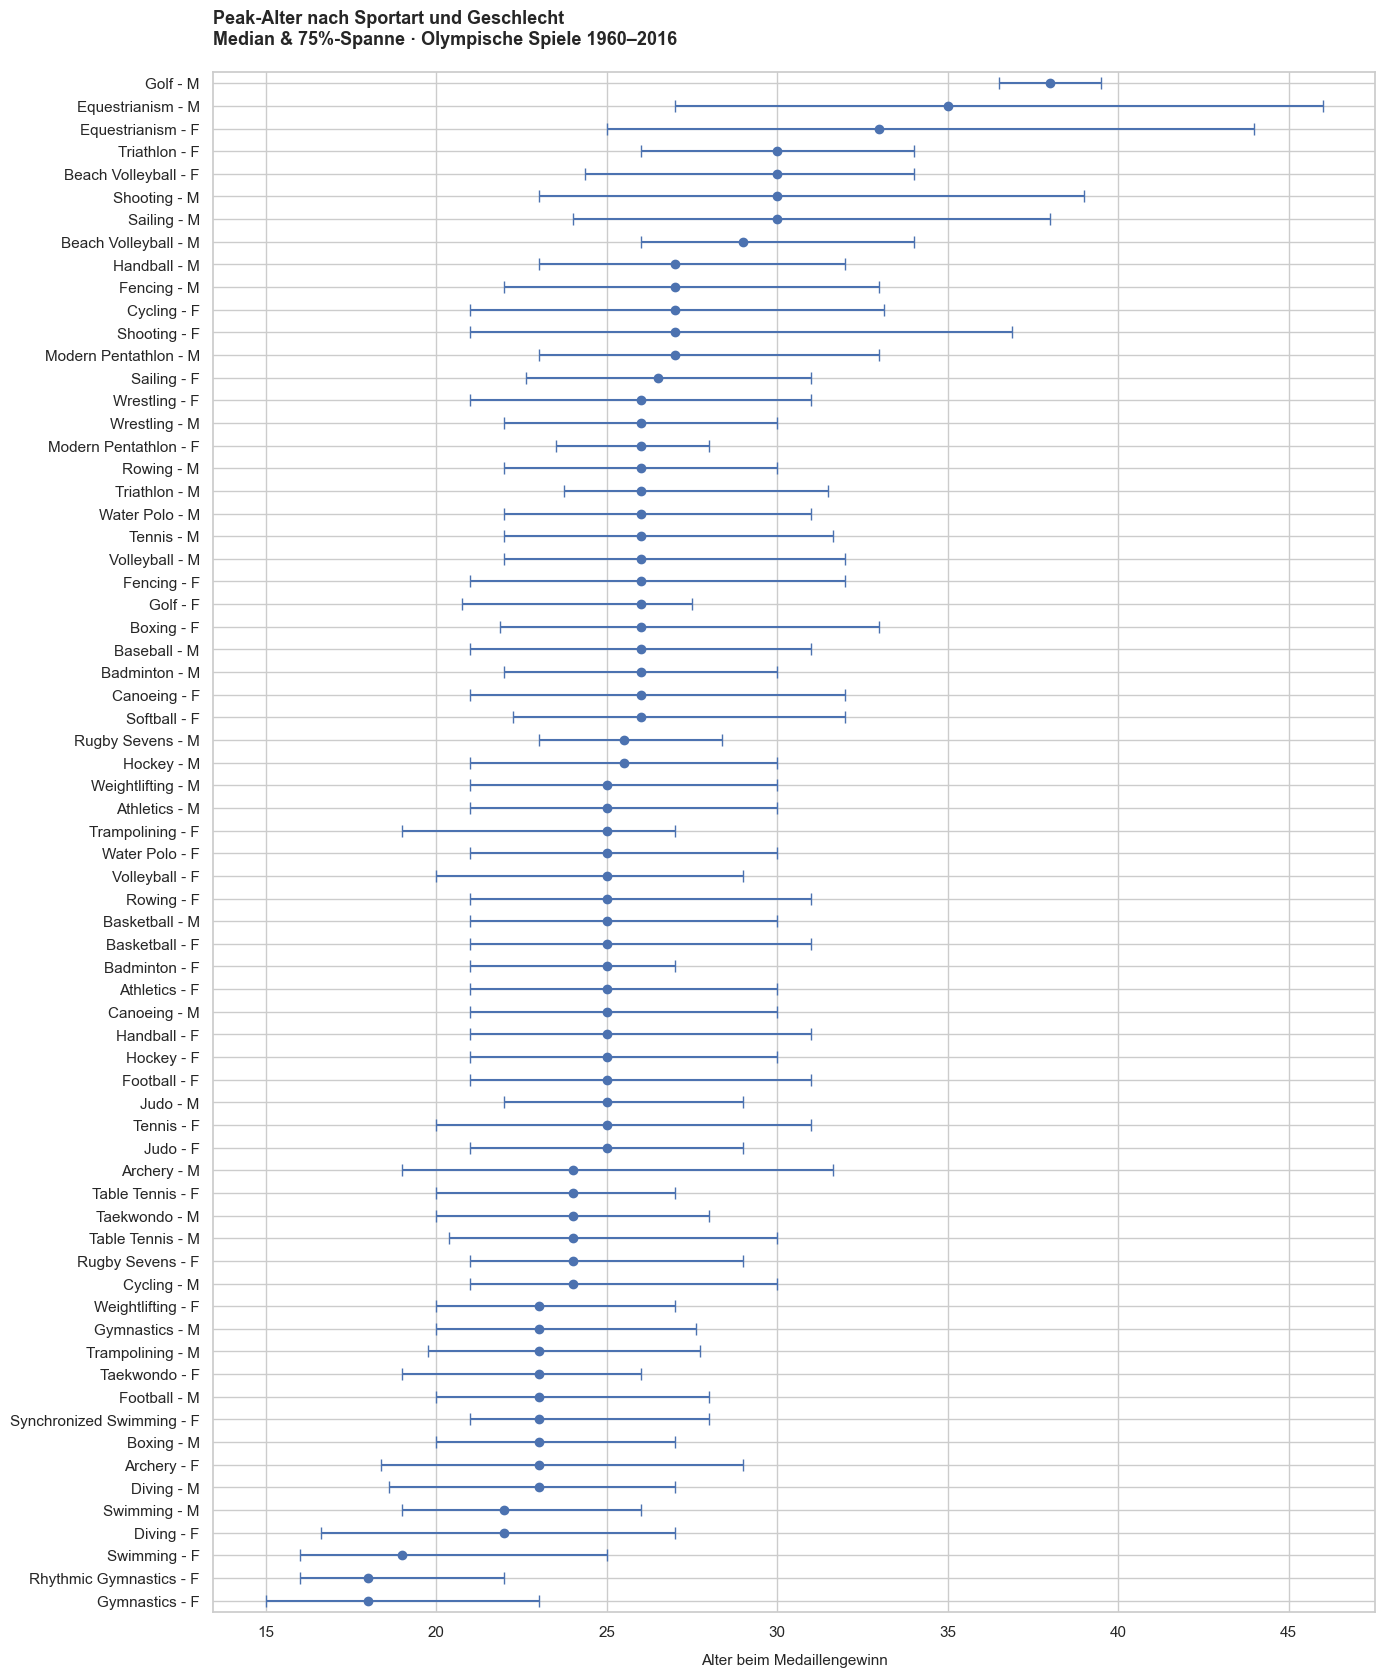

In [14]:
# Vizualize results

df_peak_summary["Lower Border"] = df_peak_summary["Medianes Medaillenalter"] - df_peak_summary["12.5%-Quartil"]
df_peak_summary["Upper Border"] = df_peak_summary["87.5%-Quartil"] - df_peak_summary["Medianes Medaillenalter"]

df_peak_summary = df_peak_summary.sort_values("Medianes Medaillenalter")

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(15, 20))

ax.errorbar(
    x=df_peak_summary["Medianes Medaillenalter"],
    y=[" - ".join([i[0], i[1]]) for i in df_peak_summary.index],
    xerr=[df_peak_summary["Lower Border"], df_peak_summary["Upper Border"]],
    fmt="o",
    capsize=4,
)

ax.set_title("Peak-Alter nach Sportart und Geschlecht\nMedian & 75%-Spanne · Olympische Spiele 1960–2016",
             fontsize=13, fontweight="bold", loc="left", pad=20)

ax.set_xlabel("Alter beim Medaillengewinn", fontsize=11, labelpad=10)
ax.set_ylim(-0.5, len(df_peak_summary) - 0.5)

plt.show()

**Result Peak age analysis**
- Rhythmic Gymnastics (Women): Median age 18  — narrowest performance window
- Equestrianism (Men): Median age 35  — longest performance window
- Most sports: 23–27 years
- Gender difference: greater in physical sports, smaller in technical sports